# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Silvana Yulia Damara
- **ID Dicoding:** CDCC132D6X0174

## Deskripsi Proyek

Proyek ini bertujuan untuk menganalisis **E-Commerce Public Dataset** guna memahami performa penjualan, kategori produk, segmentasi pelanggan, dan distribusi transaksi berdasarkan wilayah. Analisis dilakukan melalui tahapan data wrangling, exploratory data analysis, visualization & explanatory analysis, RFM analysis, geospatial/state analysis, serta penyusunan rekomendasi bisnis.

## Pertanyaan Bisnis

1. **Kategori produk apa yang menghasilkan revenue tertinggi selama periode transaksi pada dataset, dan bagaimana hubungannya dengan tingkat kepuasan pelanggan berdasarkan review score?**

   - Specific: fokus pada kategori produk, revenue, dan review score.
   - Measurable: menggunakan total revenue, jumlah order, dan rata-rata review score.
   - Action-oriented: hasilnya dapat digunakan untuk menentukan prioritas promosi dan perbaikan kualitas layanan.
   - Relevant: kategori produk adalah aspek penting dalam performa bisnis e-commerce.
   - Time-bound: periode mengikuti rentang transaksi yang tersedia pada dataset.

2. **Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary selama periode transaksi pada dataset, dan strategi retensi apa yang sesuai untuk tiap segmen?**

   - Specific: fokus pada segmentasi pelanggan.
   - Measurable: menggunakan nilai recency, frequency, dan monetary.
   - Action-oriented: hasilnya dapat digunakan untuk strategi retensi pelanggan.
   - Relevant: segmentasi pelanggan membantu bisnis meningkatkan loyalitas dan pembelian ulang.
   - Time-bound: periode mengikuti rentang transaksi yang tersedia pada dataset.

3. **Wilayah/state mana yang memberikan kontribusi order dan revenue terbesar selama periode transaksi pada dataset, dan bagaimana implikasinya terhadap strategi pemasaran serta logistik?**

   - Specific: fokus pada state pelanggan.
   - Measurable: menggunakan total order, total customer, dan total revenue.
   - Action-oriented: hasilnya dapat digunakan untuk prioritas pemasaran dan logistik.
   - Relevant: wilayah pelanggan memengaruhi distribusi bisnis e-commerce.
   - Time-bound: periode mengikuti rentang transaksi yang tersedia pada dataset.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from pathlib import Path
import os
import shutil

PROJECT_DIR = Path("/content/drive/MyDrive/submission1")
DATA_DIR = PROJECT_DIR / "data"
SUBMISSION_DIR = PROJECT_DIR / "submission"
DASHBOARD_DIR = SUBMISSION_DIR / "dashboard"

DATA_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print("Folder proyek:", PROJECT_DIR)
print("Folder data:", DATA_DIR)
print("Folder submission:", SUBMISSION_DIR)
print("Folder dashboard:", DASHBOARD_DIR)

print("\nIsi folder data:")
for file in DATA_DIR.iterdir():
    print("-", file.name)

Folder proyek: /content/drive/MyDrive/submission1
Folder data: /content/drive/MyDrive/submission1/data
Folder submission: /content/drive/MyDrive/submission1/submission
Folder dashboard: /content/drive/MyDrive/submission1/submission/dashboard

Isi folder data:
- customers_dataset.csv
- geolocation_dataset.csv
- New Text Document.txt
- order_items_dataset.csv
- sellers_dataset.csv
- order_reviews_dataset.csv
- orders_dataset.csv
- order_payments_dataset.csv
- product_category_name_translation.csv
- products_dataset.csv


## Import Library

Library yang digunakan dalam proyek ini adalah:

- `pandas` dan `numpy` untuk pengolahan data.
- `matplotlib` dan `seaborn` untuk visualisasi data.
- `IPython.display.Markdown` untuk menampilkan insight otomatis di notebook.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Data Wrangling

### Gathering Data

Dataset yang digunakan adalah **E-Commerce Public Dataset**.

Pastikan semua file CSV berikut sudah di-upload ke folder:

`MyDrive/Dicoding_Ecommerce_Submission/data/`

Daftar file yang dibutuhkan:

- `customers_dataset.csv`
- `geolocation_dataset.csv`
- `order_items_dataset.csv`
- `order_payments_dataset.csv`
- `order_reviews_dataset.csv`
- `orders_dataset.csv`
- `products_dataset.csv`
- `sellers_dataset.csv`
- `product_category_name_translation.csv`

In [12]:
required_files = {
    "customers": "customers_dataset.csv",
    "geolocation": "geolocation_dataset.csv",
    "order_items": "order_items_dataset.csv",
    "order_payments": "order_payments_dataset.csv",
    "order_reviews": "order_reviews_dataset.csv",
    "orders": "orders_dataset.csv",
    "products": "products_dataset.csv",
    "sellers": "sellers_dataset.csv",
    "translation": "product_category_name_translation.csv"
}

missing_files = []

for key, filename in required_files.items():
    file_path = DATA_DIR / filename
    if not file_path.exists():
        missing_files.append(filename)

if missing_files:
    print("File berikut belum ditemukan di folder data:")
    for file in missing_files:
        print("-", file)
    raise FileNotFoundError("Upload semua file dataset ke folder data, lalu jalankan ulang cell ini.")
else:
    print("Semua file dataset ditemukan.")

Semua file dataset ditemukan.


In [13]:
customers = pd.read_csv(DATA_DIR / "customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "geolocation_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "order_items_dataset.csv")
order_payments = pd.read_csv(DATA_DIR / "order_payments_dataset.csv")
order_reviews = pd.read_csv(DATA_DIR / "order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "orders_dataset.csv")
products = pd.read_csv(DATA_DIR / "products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "sellers_dataset.csv")
translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation
}

summary_shape = pd.DataFrame({
    "dataset": list(datasets.keys()),
    "jumlah_baris": [df.shape[0] for df in datasets.values()],
    "jumlah_kolom": [df.shape[1] for df in datasets.values()]
})

display(summary_shape)

,dataset,jumlah_baris,jumlah_kolom
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,products,32951,9
7,sellers,3095,4
8,translation,71,2


In [14]:
for name, df in datasets.items():
    display(Markdown(f"### Dataset: `{name}`"))
    display(df.head())

### Dataset: `customers`

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Dataset: `geolocation`

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


### Dataset: `order_items`

...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


### Dataset: `sellers`

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Dataset: `translation`

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Assessing Data

Pada tahap ini dilakukan penilaian kualitas data dengan mengecek:

- tipe data,
- missing value,
- duplicate data,
- statistik deskriptif,
- kemungkinan nilai tidak valid atau tidak konsisten.

In [15]:
assessment_rows = []

for name, df in datasets.items():
    assessment_rows.append({
        "dataset": name,
        "jumlah_baris": df.shape[0],
        "jumlah_kolom": df.shape[1],
        "jumlah_missing_value": int(df.isna().sum().sum()),
        "jumlah_duplicate": int(df.duplicated().sum())
    })

assessment_summary = pd.DataFrame(assessment_rows)
display(assessment_summary)

,dataset,jumlah_baris,jumlah_kolom,jumlah_missing_value,jumlah_duplicate
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
4,order_reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,translation,71,2,0,0


In [16]:
for name, df in datasets.items():
    display(Markdown(f"### Info Dataset: `{name}`"))
    print(df.info())

    display(Markdown("**Missing value per kolom:**"))
    display(df.isna().sum().reset_index().rename(columns={"index": "kolom", 0: "jumlah_missing"}))

    display(Markdown("**Jumlah duplicate:**"))
    print(df.duplicated().sum())

### Info Dataset: `customers`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None


**Missing value per kolom:**

,kolom,jumlah_missing
0,customer_id,0
1,customer_unique_id,0
2,customer_zip_code_prefix,0
3,customer_city,0
4,customer_state,0


**Jumlah duplicate:**

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None


**Missing value per kolom:**

,kolom,jumlah_missing
0,product_category_name,0
1,product_category_name_english,0


**Jumlah duplicate:**

0


In [17]:
for name, df in datasets.items():
    display(Markdown(f"### Statistik Deskriptif: `{name}`"))
    display(df.describe(include="all"))

### Statistik Deskriptif: `customers`

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,"99,441.00",99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,"35,137.47",NaN,NaN
std,NaN,NaN,"29,797.94",NaN,NaN
min,NaN,NaN,"1,003.00",NaN,NaN
25%,NaN,NaN,"11,347.00",NaN,NaN
50%,NaN,NaN,"24,416.00",NaN,NaN
75%,NaN,NaN,"58,900.00",NaN,NaN


### Statistik Deskriptif: `geolocation`

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,"1,000,163.00","1,000,163.00","1,000,163.00",1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,"36,574.17",-21.18,-46.39,NaN,NaN
std,"30,549.34",5.72,4.27,NaN,NaN
min,"1,001.00",-36.61,-101.47,NaN,NaN
25%,"11,075.00",-23.60,-48.57,NaN,NaN
50%,"26,530.00",-22.92,-46.64,NaN,NaN
75%,"63,504.00",-19.98,-43.77,NaN,NaN


### Statistik Deskriptif: `order_items`

...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,"32,341.00","32,341.00","32,341.00","32,949.00","32,949.00","32,949.00","32,949.00"
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.48,771.50,2.19,"2,276.47",30.82,16.94,23.20
std,NaN,NaN,10.25,635.12,1.74,"4,282.04",16.91,13.64,12.08
min,NaN,NaN,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,NaN,NaN,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,NaN,NaN,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,NaN,NaN,57.00,972.00,3.00,"1,900.00",38.00,21.00,30.00


### Statistik Deskriptif: `sellers`

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,"3,095.00",3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,"32,291.06",NaN,NaN
std,NaN,"32,713.45",NaN,NaN
min,NaN,"1,001.00",NaN,NaN
25%,NaN,"7,093.50",NaN,NaN
50%,NaN,"14,940.00",NaN,NaN
75%,NaN,"64,552.50",NaN,NaN


### Statistik Deskriptif: `translation`

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


### Temuan Awal Kualitas Data

Berdasarkan proses assessing data, beberapa potensi masalah yang perlu ditangani adalah:

1. Beberapa kolom tanggal pada dataset `orders` masih bertipe object/string sehingga perlu diubah menjadi tipe datetime.
2. Terdapat missing value pada beberapa kolom waktu pengiriman di dataset `orders`, khususnya untuk pesanan yang belum terkirim atau dibatalkan.
3. Terdapat missing value pada beberapa atribut produk di dataset `products`.
4. Dataset `geolocation` berpotensi memiliki data duplikat karena satu kode pos dapat muncul lebih dari satu kali.

### Rencana Cleaning

1. Mengubah kolom tanggal pada dataset `orders` menjadi tipe datetime.
2. Menghapus duplikasi pada dataset `geolocation`.
3. Menggabungkan data produk dengan tabel translasi kategori produk.
4. Mengisi kategori produk berbahasa Inggris yang kosong dengan kategori asli atau nilai `unknown`.
5. Memfokuskan analisis transaksi pada order dengan status `delivered` agar analisis revenue dan kepuasan pelanggan lebih akurat.

### Cleaning Data

In [18]:
customers_clean = customers.copy()
geolocation_clean = geolocation.copy()
order_items_clean = order_items.copy()
order_payments_clean = order_payments.copy()
order_reviews_clean = order_reviews.copy()
orders_clean = orders.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()
translation_clean = translation.copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

geolocation_before = geolocation_clean.shape[0]
geolocation_clean = geolocation_clean.drop_duplicates()
geolocation_after = geolocation_clean.shape[0]

products_clean = products_clean.merge(
    translation_clean,
    on="product_category_name",
    how="left"
)

products_clean["product_category_name_english"] = products_clean["product_category_name_english"].fillna(
    products_clean["product_category_name"]
)

products_clean["product_category_name_english"] = products_clean["product_category_name_english"].fillna("unknown")

orders_before = orders_clean.shape[0]
orders_clean = orders_clean[orders_clean["order_status"] == "delivered"].copy()
orders_after = orders_clean.shape[0]

cleaning_summary = pd.DataFrame({
    "proses": [
        "Menghapus duplikasi geolocation",
        "Memfilter order dengan status delivered"
    ],
    "jumlah_awal": [geolocation_before, orders_before],
    "jumlah_akhir": [geolocation_after, orders_after],
    "jumlah_terhapus": [geolocation_before - geolocation_after, orders_before - orders_after]
})

display(cleaning_summary)

,proses,jumlah_awal,jumlah_akhir,jumlah_terhapus
0,Menghapus duplikasi geolocation,1000163,738332,261831
1,Memfilter order dengan status delivered,99441,96478,2963


In [19]:
display(Markdown("### Validasi Tipe Data Orders Setelah Cleaning"))
display(orders_clean.dtypes.reset_index().rename(columns={"index": "kolom", 0: "tipe_data"}))

display(Markdown("### Missing Value Products Setelah Translasi Kategori"))
display(products_clean.isna().sum().reset_index().rename(columns={"index": "kolom", 0: "jumlah_missing"}))

display(Markdown("### Duplicate Geolocation Setelah Cleaning"))
print(geolocation_clean.duplicated().sum())

### Validasi Tipe Data Orders Setelah Cleaning

,kolom,tipe_data
0,order_id,object
1,customer_id,object
2,order_status,object
3,order_purchase_timestamp,datetime64[ns]
4,order_approved_at,datetime64[ns]
5,order_delivered_carrier_date,datetime64[ns]
6,order_delivered_customer_date,datetime64[ns]
7,order_estimated_delivery_date,datetime64[ns]


### Missing Value Products Setelah Translasi Kategori

,kolom,jumlah_missing
0,product_id,0
1,product_category_name,610
2,product_name_lenght,610
3,product_description_lenght,610
4,product_photos_qty,610
5,product_weight_g,2
6,product_length_cm,2
7,product_height_cm,2
8,product_width_cm,2
9,product_category_name_english,0


### Duplicate Geolocation Setelah Cleaning

0


## Membuat Data Utama untuk Analisis

Data utama dibuat dengan menggabungkan:

- data order,
- item produk,
- pelanggan,
- penjual,
- pembayaran,
- review,
- kategori produk.

Kolom `revenue` dihitung sebagai:

`revenue = price + freight_value`

Nilai ini digunakan untuk melihat nilai transaksi termasuk ongkos kirim.

In [20]:
payment_agg = order_payments_clean.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_installments": "mean"
}).reset_index()

review_agg = order_reviews_clean.groupby("order_id").agg({
    "review_score": "mean"
}).reset_index()

main_data = order_items_clean.merge(orders_clean, on="order_id", how="inner")
main_data = main_data.merge(customers_clean, on="customer_id", how="left")
main_data = main_data.merge(products_clean, on="product_id", how="left")
main_data = main_data.merge(sellers_clean, on="seller_id", how="left")
main_data = main_data.merge(payment_agg, on="order_id", how="left")
main_data = main_data.merge(review_agg, on="order_id", how="left")

main_data["revenue"] = main_data["price"] + main_data["freight_value"]
main_data["order_month"] = main_data["order_purchase_timestamp"].dt.to_period("M").astype(str)
main_data["order_year"] = main_data["order_purchase_timestamp"].dt.year

main_data["delivery_time_days"] = (
    main_data["order_delivered_customer_date"] - main_data["order_purchase_timestamp"]
).dt.days

main_data["estimated_vs_actual_days"] = (
    main_data["order_estimated_delivery_date"] - main_data["order_delivered_customer_date"]
).dt.days

display(main_data.head())
print("Ukuran main_data:", main_data.shape)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score,revenue,order_month,order_year,delivery_time_days,estimated_vs_actual_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,volta redonda,SP,72.19,2.00,5.00,72.19,2017-09,2017,7.00,8.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,sao paulo,SP,259.83,3.00,4.00,259.83,2017-04,2017,16.00,2.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,borda da mata,MG,216.87,5.00,5.00,216.87,2018-01,2018,7.00,13.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,franca,SP,25.78,2.00,4.00,25.78,2018-08,2018,6.00,5.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,loanda,PR,218.04,3.00,5.00,218.04,2017-02,2017,25.00,15.00


Ukuran main_data: (110197, 38)


In [21]:
display(Markdown("### Ringkasan Main Data"))

display(pd.DataFrame({
    "metrik": [
        "jumlah_baris",
        "jumlah_order_unik",
        "jumlah_customer_unik",
        "jumlah_produk_unik",
        "periode_awal",
        "periode_akhir",
        "total_revenue"
    ],
    "nilai": [
        main_data.shape[0],
        main_data["order_id"].nunique(),
        main_data["customer_unique_id"].nunique(),
        main_data["product_id"].nunique(),
        main_data["order_purchase_timestamp"].min(),
        main_data["order_purchase_timestamp"].max(),
        main_data["revenue"].sum()
    ]
}))

### Ringkasan Main Data

,metrik,nilai
0,jumlah_baris,110197
1,jumlah_order_unik,96478
2,jumlah_customer_unik,93358
3,jumlah_produk_unik,32216
4,periode_awal,2016-09-15 12:16:38
5,periode_akhir,2018-08-29 15:00:37
6,total_revenue,"15,419,773.75"


## Exploratory Data Analysis

Tahap EDA digunakan untuk memahami pola pada data dan menjawab pertanyaan bisnis.

In [22]:
monthly_revenue = main_data.groupby("order_month").agg({
    "revenue": "sum",
    "order_id": "nunique",
    "customer_unique_id": "nunique",
    "review_score": "mean"
}).reset_index()

monthly_revenue.columns = [
    "order_month",
    "total_revenue",
    "total_orders",
    "total_customers",
    "avg_review_score"
]

display(monthly_revenue.head())
display(monthly_revenue.tail())

,order_month,total_revenue,total_orders,total_customers,avg_review_score
0,2016-09,143.46,1,1,1.00
1,2016-10,"46,490.66",265,262,3.90
2,2016-12,19.62,1,1,5.00
3,2017-01,"127,482.37",750,718,4.16
4,2017-02,"271,239.32",1653,1630,4.18


,order_month,total_revenue,total_orders,total_customers,avg_review_score
18,2018-04,"1,132,878.93",6798,6744,4.11
19,2018-05,"1,128,774.52",6749,6693,4.16
20,2018-06,"1,011,978.29",6099,6061,4.21
21,2018-07,"1,027,807.28",6159,6100,4.27
22,2018-08,"985,491.64",6351,6310,4.25


In [23]:
peak_month = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmin()]

display(Markdown(f"""
### Insight EDA Revenue Bulanan

- Periode transaksi pada dataset dimulai dari **{main_data['order_purchase_timestamp'].min().date()}** sampai **{main_data['order_purchase_timestamp'].max().date()}**.
- Revenue bulanan tertinggi terjadi pada **{peak_month['order_month']}** dengan total revenue sebesar **R$ {peak_month['total_revenue']:,.2f}**.
- Revenue bulanan terendah terjadi pada **{lowest_month['order_month']}** dengan total revenue sebesar **R$ {lowest_month['total_revenue']:,.2f}**.
"""))


### Insight EDA Revenue Bulanan

- Periode transaksi pada dataset dimulai dari **2016-09-15** sampai **2018-08-29**.
- Revenue bulanan tertinggi terjadi pada **2017-11** dengan total revenue sebesar **R$ 1,153,364.20**.
- Revenue bulanan terendah terjadi pada **2016-12** dengan total revenue sebesar **R$ 19.62**.


In [24]:
category_analysis = main_data.groupby("product_category_name_english").agg({
    "revenue": "sum",
    "order_id": "nunique",
    "review_score": "mean",
    "customer_unique_id": "nunique"
}).reset_index()

category_analysis.columns = [
    "category",
    "total_revenue",
    "total_orders",
    "avg_review_score",
    "total_customers"
]

category_analysis = category_analysis.sort_values("total_revenue", ascending=False)

display(category_analysis.head(10))

,category,total_revenue,total_orders,avg_review_score,total_customers
43,health_beauty,"1,412,089.53",8647,4.19,8498
73,watches_gifts,"1,264,333.12",5495,4.07,5421
7,bed_bath_table,"1,225,209.26",9272,3.92,9008
67,sports_leisure,"1,118,256.91",7530,4.17,7341
15,computers_accessories,"1,032,723.77",6530,3.99,6405
39,furniture_decor,"880,329.92",6307,3.95,6178
49,housewares,"758,392.25",5743,4.11,5681
20,cool_stuff,"691,680.89",3559,4.19,3543
5,auto,"669,454.75",3810,4.12,3769
42,garden_tools,"567,145.68",3448,4.08,3420


In [25]:
top_category = category_analysis.iloc[0]

eligible_review_categories = category_analysis[category_analysis["total_orders"] >= 50]

if eligible_review_categories.empty:
    eligible_review_categories = category_analysis.copy()

top_review_category = eligible_review_categories.sort_values(
    "avg_review_score",
    ascending=False
).iloc[0]

display(Markdown(f"""
### Insight EDA Kategori Produk

- Kategori dengan revenue tertinggi adalah **{top_category['category']}** dengan total revenue **R$ {top_category['total_revenue']:,.2f}** dan jumlah order **{int(top_category['total_orders']):,}**.
- Untuk kategori dengan jumlah order yang memadai, rata-rata review score tertinggi dimiliki oleh **{top_review_category['category']}** dengan skor **{top_review_category['avg_review_score']:.2f}**.
- Perbandingan revenue dan review score membantu bisnis menentukan apakah kategori yang bernilai tinggi juga sudah memiliki kepuasan pelanggan yang baik.
"""))


### Insight EDA Kategori Produk

- Kategori dengan revenue tertinggi adalah **health_beauty** dengan total revenue **R$ 1,412,089.53** dan jumlah order **8,647**.
- Untuk kategori dengan jumlah order yang memadai, rata-rata review score tertinggi dimiliki oleh **books_general_interest** dengan skor **4.51**.
- Perbandingan revenue dan review score membantu bisnis menentukan apakah kategori yang bernilai tinggi juga sudah memiliki kepuasan pelanggan yang baik.


In [26]:
state_analysis = main_data.groupby("customer_state").agg({
    "order_id": "nunique",
    "customer_unique_id": "nunique",
    "revenue": "sum",
    "review_score": "mean",
    "delivery_time_days": "mean"
}).reset_index()

state_analysis.columns = [
    "state",
    "total_orders",
    "total_customers",
    "total_revenue",
    "avg_review_score",
    "avg_delivery_time_days"
]

state_analysis = state_analysis.sort_values("total_revenue", ascending=False)

display(state_analysis.head(10))

,state,total_orders,total_customers,total_revenue,avg_review_score,avg_delivery_time_days
25,SP,40501,39156,"5,769,703.15",4.18,8.26
18,RJ,12350,11917,"2,055,401.57",3.87,14.69
10,MG,11354,11001,"1,818,891.67",4.12,11.51
22,RS,5345,5168,"861,472.79",4.09,14.71
17,PR,4923,4769,"781,708.80",4.15,11.48
23,SC,3546,3449,"595,127.78",4.05,14.52
4,BA,3256,3158,"591,137.81",3.86,18.77
6,DF,2080,2019,"346,123.35",4.06,12.50
8,GO,1957,1895,"334,212.35",4.04,14.95
7,ES,1995,1928,"317,657.93",4.01,15.19


In [27]:
top_state = state_analysis.iloc[0]

display(Markdown(f"""
### Insight EDA Wilayah

- State dengan revenue tertinggi adalah **{top_state['state']}** dengan total revenue **R$ {top_state['total_revenue']:,.2f}**.
- State tersebut memiliki **{int(top_state['total_orders']):,}** order unik dan **{int(top_state['total_customers']):,}** pelanggan unik.
- Informasi ini dapat digunakan untuk menentukan prioritas pemasaran, pengelolaan stok, dan optimasi logistik.
"""))


### Insight EDA Wilayah

- State dengan revenue tertinggi adalah **SP** dengan total revenue **R$ 5,769,703.15**.
- State tersebut memiliki **40,501** order unik dan **39,156** pelanggan unik.
- Informasi ini dapat digunakan untuk menentukan prioritas pemasaran, pengelolaan stok, dan optimasi logistik.


## Visualization & Explanatory Analysis

Bagian ini menyajikan visualisasi untuk menjawab pertanyaan bisnis.

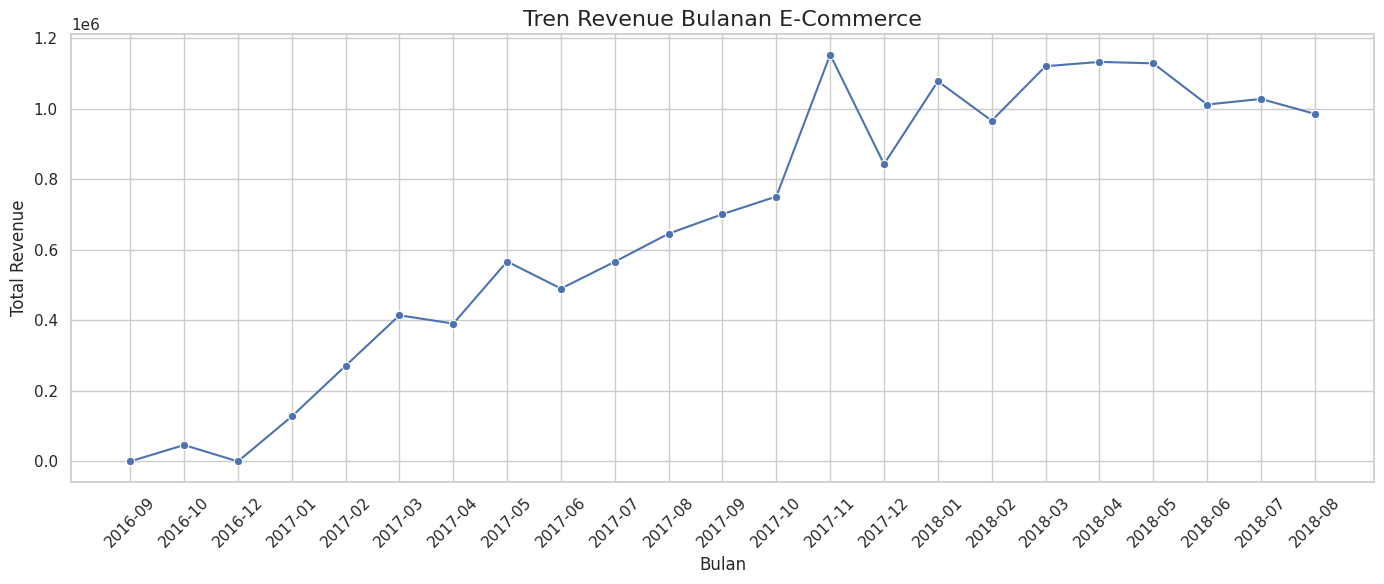

In [28]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_revenue,
    x="order_month",
    y="total_revenue",
    marker="o"
)

plt.title("Tren Revenue Bulanan E-Commerce", fontsize=16)
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Penjelasan Visualisasi Revenue Bulanan

Grafik garis digunakan karena cocok untuk menunjukkan perubahan revenue dari waktu ke waktu. Dari grafik ini, bisnis dapat melihat periode dengan performa revenue tinggi maupun rendah.

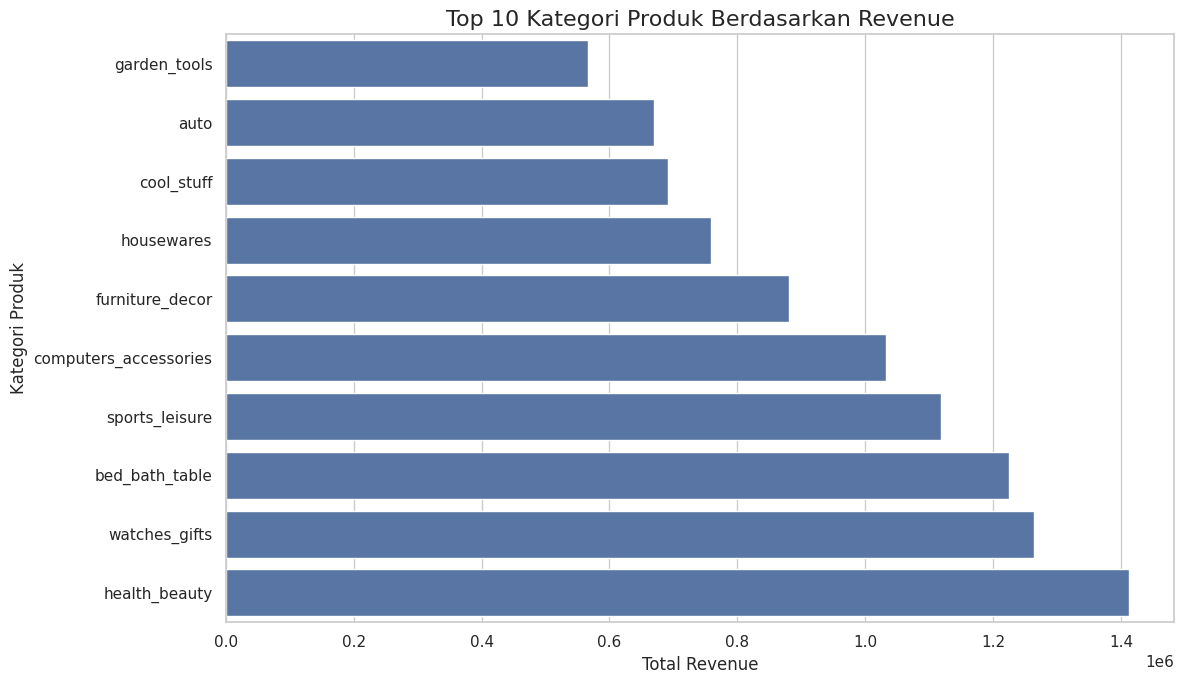

In [29]:
top_10_categories = category_analysis.head(10).sort_values("total_revenue", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_10_categories,
    x="total_revenue",
    y="category"
)

plt.title("Top 10 Kategori Produk Berdasarkan Revenue", fontsize=16)
plt.xlabel("Total Revenue")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

# Bagian Baru

### Penjelasan Visualisasi Kategori Produk

Bar chart horizontal digunakan agar nama kategori produk mudah dibaca. Visualisasi ini menjawab pertanyaan bisnis pertama terkait kategori produk dengan kontribusi revenue terbesar.

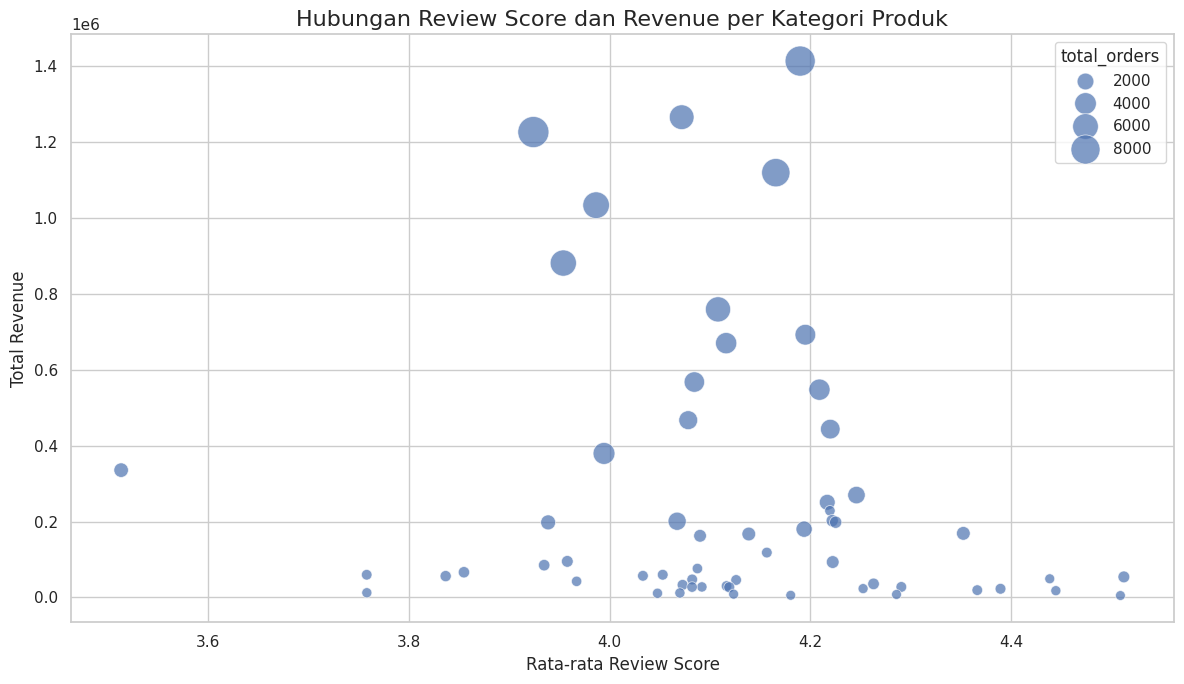

In [31]:
category_scatter = category_analysis[category_analysis["total_orders"] >= 50].copy()

if category_scatter.empty:
    category_scatter = category_analysis.copy()

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=category_scatter,
    x="avg_review_score",
    y="total_revenue",
    size="total_orders",
    sizes=(50, 500),
    alpha=0.7
)

plt.title("Hubungan Review Score dan Revenue per Kategori Produk", fontsize=16)
plt.xlabel("Rata-rata Review Score")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# Bagian Baru

### Penjelasan Visualisasi Revenue vs Review Score

Scatter plot digunakan untuk melihat hubungan antara rata-rata review score dan total revenue. Ukuran titik merepresentasikan jumlah order. Kategori dengan revenue tinggi tetapi review score rendah dapat menjadi prioritas perbaikan kualitas produk atau layanan.

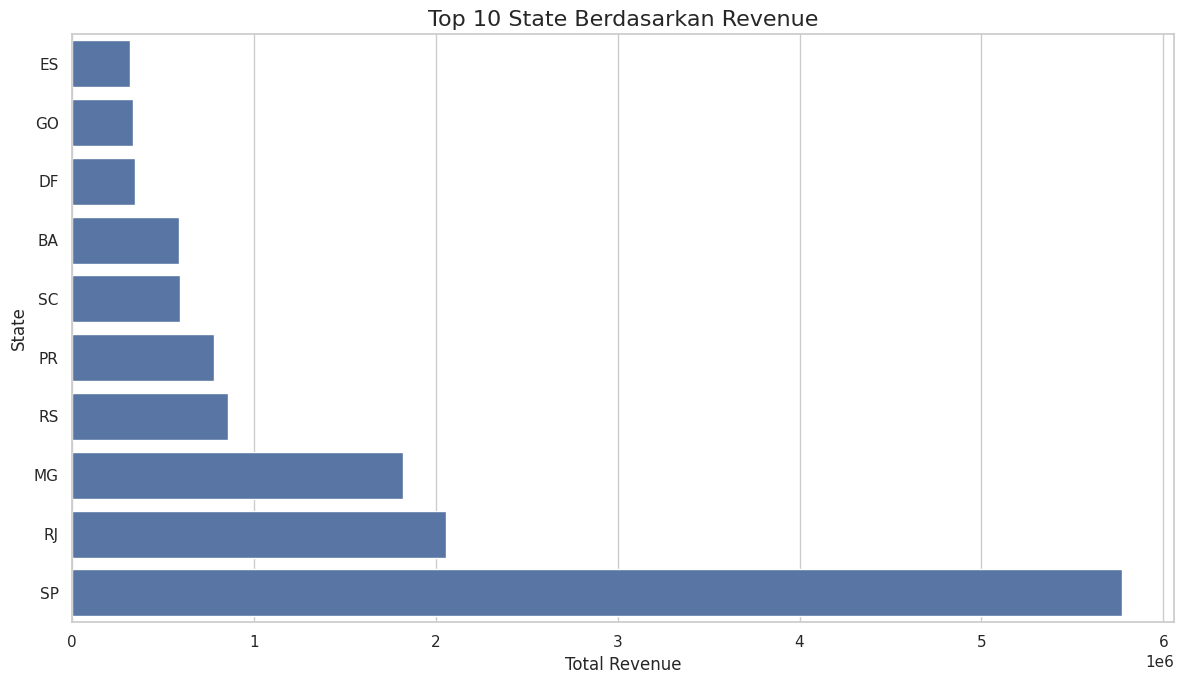

In [32]:
top_10_states = state_analysis.head(10).sort_values("total_revenue", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_10_states,
    x="total_revenue",
    y="state"
)

plt.title("Top 10 State Berdasarkan Revenue", fontsize=16)
plt.xlabel("Total Revenue")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Penjelasan Visualisasi Wilayah

Visualisasi ini menjawab pertanyaan bisnis ketiga, yaitu wilayah yang memberikan kontribusi revenue terbesar. Hasilnya dapat digunakan untuk strategi pemasaran dan logistik berbasis wilayah.

## Analisis Lanjutan: RFM Analysis

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan perilaku transaksi:

- **Recency:** jumlah hari sejak transaksi terakhir pelanggan.
- **Frequency:** jumlah transaksi yang dilakukan pelanggan.
- **Monetary:** total nilai transaksi pelanggan.

Analisis ini relevan untuk membantu bisnis menentukan strategi retensi pelanggan.

In [33]:
snapshot_date = main_data["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = main_data.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "revenue": "sum"
}).reset_index()

rfm.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

def segment_customer(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Best Customers"
    elif row["r_score"] >= 3 and row["f_score"] >= 3:
        return "Loyal Customers"
    elif row["r_score"] >= 3 and row["f_score"] <= 2:
        return "New/Potential Customers"
    elif row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk"
    elif row["r_score"] <= 2 and row["f_score"] <= 2:
        return "Hibernating"
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

display(rfm.head())

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413,New/Potential Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311,New/Potential Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,Hibernating


In [34]:
segment_summary = rfm.groupby("segment").agg({
    "customer_unique_id": "count",
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
}).reset_index()

segment_summary.columns = [
    "segment",
    "total_customers",
    "avg_recency",
    "avg_frequency",
    "avg_monetary"
]

segment_summary = segment_summary.sort_values("total_customers", ascending=False)

display(segment_summary)

,segment,total_customers,avg_recency,avg_frequency,avg_monetary
2,Hibernating,23355,364.97,1.00,160.92
0,At Risk,23324,363.26,1.06,166.23
4,New/Potential Customers,23324,111.91,1.00,160.92
3,Loyal Customers,21587,116.00,1.05,153.36
1,Best Customers,1768,58.23,1.36,407.56


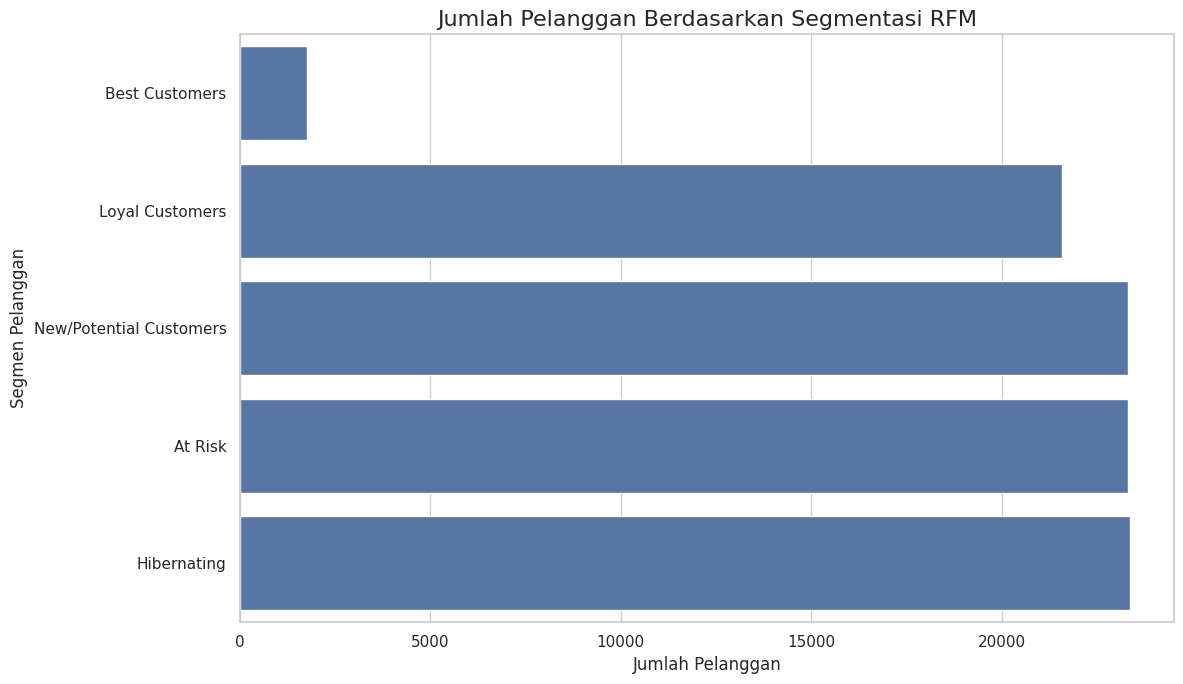

In [35]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=segment_summary.sort_values("total_customers", ascending=True),
    x="total_customers",
    y="segment"
)

plt.title("Jumlah Pelanggan Berdasarkan Segmentasi RFM", fontsize=16)
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

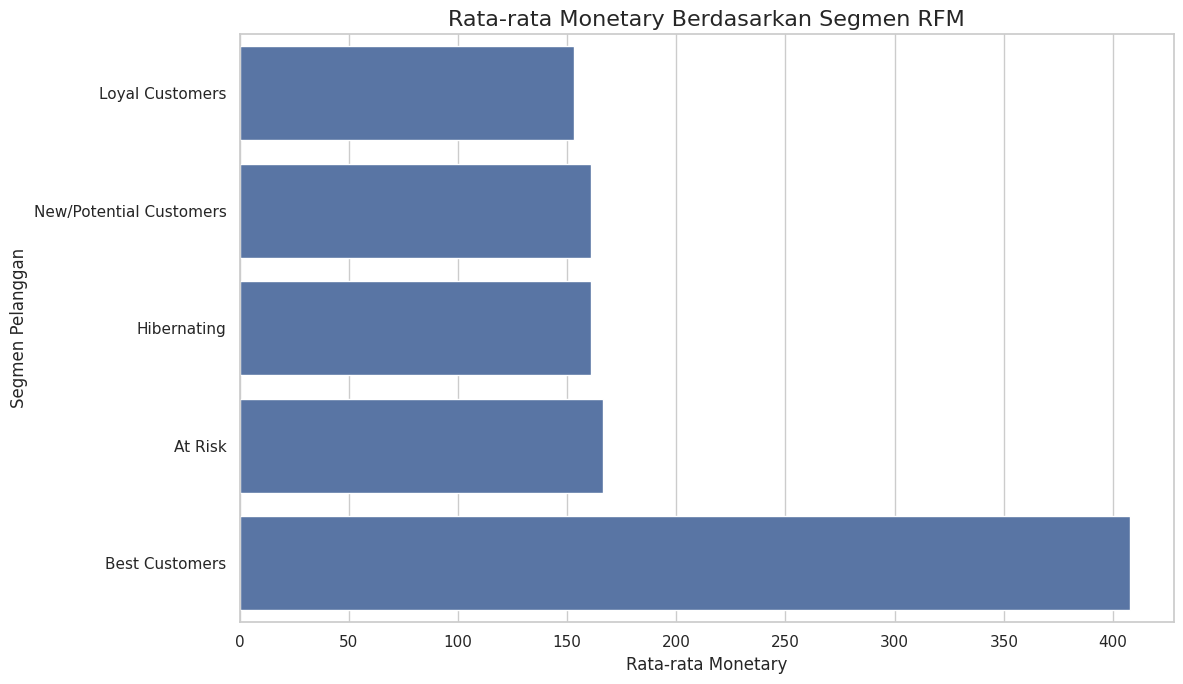

In [36]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=segment_summary.sort_values("avg_monetary", ascending=True),
    x="avg_monetary",
    y="segment"
)

plt.title("Rata-rata Monetary Berdasarkan Segmen RFM", fontsize=16)
plt.xlabel("Rata-rata Monetary")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

In [37]:
largest_segment = segment_summary.iloc[0]
highest_monetary_segment = segment_summary.sort_values("avg_monetary", ascending=False).iloc[0]

display(Markdown(f"""
### Insight RFM Analysis

- Segmen pelanggan terbesar adalah **{largest_segment['segment']}** dengan jumlah pelanggan **{int(largest_segment['total_customers']):,}**.
- Segmen dengan rata-rata monetary tertinggi adalah **{highest_monetary_segment['segment']}** dengan rata-rata monetary **R$ {highest_monetary_segment['avg_monetary']:,.2f}**.
- Pelanggan pada segmen **Best Customers** dan **Loyal Customers** dapat diprioritaskan untuk program loyalitas.
- Pelanggan pada segmen **At Risk** dan **Hibernating** dapat ditargetkan dengan promo reaktivasi, voucher personal, atau kampanye email remarketing.
"""))


### Insight RFM Analysis

- Segmen pelanggan terbesar adalah **Hibernating** dengan jumlah pelanggan **23,355**.
- Segmen dengan rata-rata monetary tertinggi adalah **Best Customers** dengan rata-rata monetary **R$ 407.56**.
- Pelanggan pada segmen **Best Customers** dan **Loyal Customers** dapat diprioritaskan untuk program loyalitas.
- Pelanggan pada segmen **At Risk** dan **Hibernating** dapat ditargetkan dengan promo reaktivasi, voucher personal, atau kampanye email remarketing.


## Analisis Lanjutan: Geospatial / State Analysis

Analisis ini menggunakan informasi wilayah pelanggan berdasarkan `customer_state`. Karena dataset memiliki kode state, analisis dilakukan pada level state untuk memahami distribusi revenue dan order.

In [38]:
state_analysis = state_analysis.copy()

state_analysis["revenue_share_pct"] = (
    state_analysis["total_revenue"] / state_analysis["total_revenue"].sum() * 100
)

state_analysis["order_share_pct"] = (
    state_analysis["total_orders"] / state_analysis["total_orders"].sum() * 100
)

display(state_analysis.head(10))

,state,total_orders,total_customers,total_revenue,avg_review_score,avg_delivery_time_days,revenue_share_pct,order_share_pct
25,SP,40501,39156,"5,769,703.15",4.18,8.26,37.42,41.98
18,RJ,12350,11917,"2,055,401.57",3.87,14.69,13.33,12.80
10,MG,11354,11001,"1,818,891.67",4.12,11.51,11.80,11.77
22,RS,5345,5168,"861,472.79",4.09,14.71,5.59,5.54
17,PR,4923,4769,"781,708.80",4.15,11.48,5.07,5.10
23,SC,3546,3449,"595,127.78",4.05,14.52,3.86,3.68
4,BA,3256,3158,"591,137.81",3.86,18.77,3.83,3.37
6,DF,2080,2019,"346,123.35",4.06,12.50,2.24,2.16
8,GO,1957,1895,"334,212.35",4.04,14.95,2.17,2.03
7,ES,1995,1928,"317,657.93",4.01,15.19,2.06,2.07


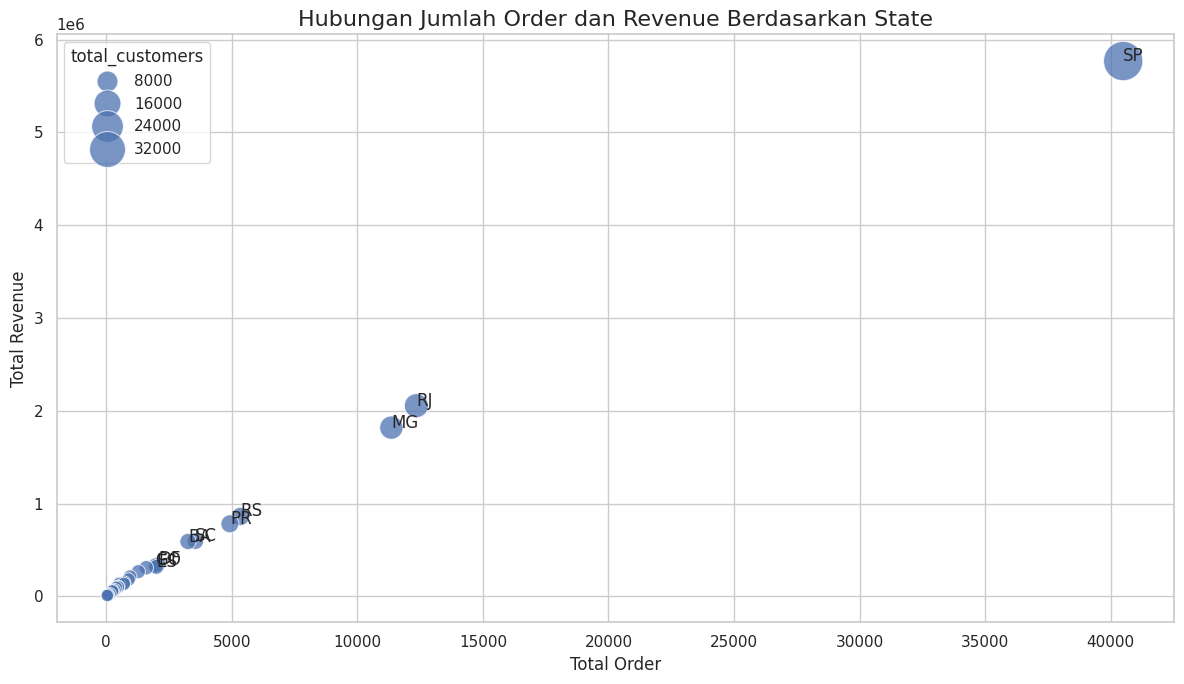

In [39]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=state_analysis,
    x="total_orders",
    y="total_revenue",
    size="total_customers",
    sizes=(80, 800),
    alpha=0.75
)

for _, row in state_analysis.head(10).iterrows():
    plt.text(row["total_orders"], row["total_revenue"], row["state"])

plt.title("Hubungan Jumlah Order dan Revenue Berdasarkan State", fontsize=16)
plt.xlabel("Total Order")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [40]:
top_state_share = state_analysis.iloc[0]

display(Markdown(f"""
### Insight Geospatial / State Analysis

- State dengan kontribusi revenue terbesar adalah **{top_state_share['state']}**.
- State ini menyumbang sekitar **{top_state_share['revenue_share_pct']:.2f}%** dari total revenue dan **{top_state_share['order_share_pct']:.2f}%** dari total order.
- Wilayah dengan kontribusi besar dapat dijadikan prioritas untuk optimasi logistik, pengadaan stok, dan kampanye pemasaran.
"""))


### Insight Geospatial / State Analysis

- State dengan kontribusi revenue terbesar adalah **SP**.
- State ini menyumbang sekitar **37.42%** dari total revenue dan **41.98%** dari total order.
- Wilayah dengan kontribusi besar dapat dijadikan prioritas untuk optimasi logistik, pengadaan stok, dan kampanye pemasaran.


## Conclusion & Recommendation

Bagian ini menjawab seluruh pertanyaan bisnis berdasarkan hasil analisis dan visualisasi.

In [41]:
top_category = category_analysis.iloc[0]
top_state = state_analysis.iloc[0]
largest_segment = segment_summary.iloc[0]
highest_monetary_segment = segment_summary.sort_values("avg_monetary", ascending=False).iloc[0]

conclusion_text = f"""
## Conclusion

### Pertanyaan 1

Kategori produk dengan revenue tertinggi selama periode transaksi adalah **{top_category['category']}** dengan total revenue sebesar **R$ {top_category['total_revenue']:,.2f}** dan jumlah order sebanyak **{int(top_category['total_orders']):,}**.

Kategori ini dapat menjadi prioritas dalam strategi promosi, pengelolaan stok, dan optimasi layanan. Review score perlu tetap diperhatikan karena kategori dengan revenue besar belum tentu selalu memiliki tingkat kepuasan pelanggan tertinggi.

### Pertanyaan 2

Berdasarkan RFM Analysis, segmen pelanggan terbesar adalah **{largest_segment['segment']}** dengan jumlah pelanggan **{int(largest_segment['total_customers']):,}**.

Sementara itu, segmen dengan rata-rata monetary tertinggi adalah **{highest_monetary_segment['segment']}** dengan rata-rata monetary **R$ {highest_monetary_segment['avg_monetary']:,.2f}**.

Segmentasi ini membantu bisnis menentukan strategi retensi yang lebih tepat sasaran.

### Pertanyaan 3

State dengan kontribusi revenue terbesar adalah **{top_state['state']}** dengan total revenue sebesar **R$ {top_state['total_revenue']:,.2f}**.

Wilayah ini juga memiliki jumlah order sebanyak **{int(top_state['total_orders']):,}**. Oleh karena itu, wilayah tersebut dapat diprioritaskan untuk strategi pemasaran, pengelolaan stok, dan optimasi pengiriman.

## Recommendation / Action Items

1. **Prioritaskan kategori revenue tinggi** untuk promosi, bundling produk, dan pengelolaan stok agar potensi pendapatan dapat dimaksimalkan.
2. **Perbaiki kategori dengan revenue tinggi tetapi review score belum optimal** melalui evaluasi kualitas produk, waktu pengiriman, dan layanan pelanggan.
3. **Buat program loyalitas untuk Best Customers dan Loyal Customers**, seperti voucher eksklusif, early access campaign, atau membership benefit.
4. **Lakukan kampanye reaktivasi untuk At Risk dan Hibernating Customers**, seperti voucher personal, email remarketing, dan promo pembelian ulang.
5. **Optimalkan strategi logistik dan pemasaran pada state dengan revenue tertinggi**, karena wilayah tersebut memiliki kontribusi besar terhadap performa bisnis.
"""

display(Markdown(conclusion_text))


## Conclusion

### Pertanyaan 1

Kategori produk dengan revenue tertinggi selama periode transaksi adalah **health_beauty** dengan total revenue sebesar **R$ 1,412,089.53** dan jumlah order sebanyak **8,647**.

Kategori ini dapat menjadi prioritas dalam strategi promosi, pengelolaan stok, dan optimasi layanan. Review score perlu tetap diperhatikan karena kategori dengan revenue besar belum tentu selalu memiliki tingkat kepuasan pelanggan tertinggi.

### Pertanyaan 2

Berdasarkan RFM Analysis, segmen pelanggan terbesar adalah **Hibernating** dengan jumlah pelanggan **23,355**.

Sementara itu, segmen dengan rata-rata monetary tertinggi adalah **Best Customers** dengan rata-rata monetary **R$ 407.56**.

Segmentasi ini membantu bisnis menentukan strategi retensi yang lebih tepat sasaran.

### Pertanyaan 3

State dengan kontribusi revenue terbesar adalah **SP** dengan total revenue sebesar **R$ 5,769,703.15**.

Wilayah ini juga memiliki jumlah order sebanyak **40,501**. Oleh karena itu, wilayah tersebut dapat diprioritaskan untuk strategi pemasaran, pengelolaan stok, dan optimasi pengiriman.

## Recommendation / Action Items

1. **Prioritaskan kategori revenue tinggi** untuk promosi, bundling produk, dan pengelolaan stok agar potensi pendapatan dapat dimaksimalkan.
2. **Perbaiki kategori dengan revenue tinggi tetapi review score belum optimal** melalui evaluasi kualitas produk, waktu pengiriman, dan layanan pelanggan.
3. **Buat program loyalitas untuk Best Customers dan Loyal Customers**, seperti voucher eksklusif, early access campaign, atau membership benefit.
4. **Lakukan kampanye reaktivasi untuk At Risk dan Hibernating Customers**, seperti voucher personal, email remarketing, dan promo pembelian ulang.
5. **Optimalkan strategi logistik dan pemasaran pada state dengan revenue tertinggi**, karena wilayah tersebut memiliki kontribusi besar terhadap performa bisnis.


## Menyimpan Data untuk Dashboard Streamlit

File hasil analisis akan disimpan ke folder:

`MyDrive/Dicoding_Ecommerce_Submission/submission/dashboard/`

File yang dibuat:

- `main_data.csv`
- `rfm_data.csv`
- `state_analysis.csv`
- `category_analysis.csv`

In [42]:
dashboard_columns = [
    "order_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_month",
    "order_year",
    "order_status",
    "product_category_name_english",
    "customer_city",
    "customer_state",
    "seller_city",
    "seller_state",
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "revenue",
    "review_score",
    "delivery_time_days",
    "estimated_vs_actual_days"
]

main_data_dashboard = main_data[dashboard_columns].copy()

main_data_dashboard.to_csv(DASHBOARD_DIR / "main_data.csv", index=False)
rfm.to_csv(DASHBOARD_DIR / "rfm_data.csv", index=False)
state_analysis.to_csv(DASHBOARD_DIR / "state_analysis.csv", index=False)
category_analysis.to_csv(DASHBOARD_DIR / "category_analysis.csv", index=False)

print("File dashboard berhasil disimpan:")
for file in DASHBOARD_DIR.iterdir():
    print("-", file.name)

File dashboard berhasil disimpan:
- main_data.csv
- rfm_data.csv
- state_analysis.csv
- category_analysis.csv


## Membuat File Dashboard Streamlit dari Colab

Cell berikut akan membuat file `dashboard.py` secara otomatis di folder dashboard.

In [43]:
dashboard_code = """
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="E-Commerce Dashboard",
    page_icon="🛒",
    layout="wide"
)

@st.cache_data
def load_data():
    main_data = pd.read_csv("dashboard/main_data.csv")
    rfm_data = pd.read_csv("dashboard/rfm_data.csv")
    state_analysis = pd.read_csv("dashboard/state_analysis.csv")
    category_analysis = pd.read_csv("dashboard/category_analysis.csv")

    main_data["order_purchase_timestamp"] = pd.to_datetime(main_data["order_purchase_timestamp"])

    return main_data, rfm_data, state_analysis, category_analysis

main_data, rfm_data, state_analysis, category_analysis = load_data()

st.title("🛒 E-Commerce Public Dataset Dashboard")
st.caption("Dashboard analisis revenue, kategori produk, segmentasi pelanggan, dan wilayah.")

min_date = main_data["order_purchase_timestamp"].min().date()
max_date = main_data["order_purchase_timestamp"].max().date()

with st.sidebar:
    st.header("Filter Data")

    date_range = st.date_input(
        "Rentang Tanggal",
        value=(min_date, max_date),
        min_value=min_date,
        max_value=max_date
    )

    selected_state = st.multiselect(
        "Pilih State",
        options=sorted(main_data["customer_state"].dropna().unique()),
        default=None
    )

filtered_df = main_data.copy()

if len(date_range) == 2:
    start_date, end_date = date_range
    filtered_df = filtered_df[
        (filtered_df["order_purchase_timestamp"].dt.date >= start_date) &
        (filtered_df["order_purchase_timestamp"].dt.date <= end_date)
    ]

if selected_state:
    filtered_df = filtered_df[filtered_df["customer_state"].isin(selected_state)]

total_revenue = filtered_df["revenue"].sum()
total_orders = filtered_df["order_id"].nunique()
total_customers = filtered_df["customer_unique_id"].nunique()
avg_review = filtered_df["review_score"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Revenue", f"R$ {total_revenue:,.0f}")
col2.metric("Total Orders", f"{total_orders:,}")
col3.metric("Total Customers", f"{total_customers:,}")
col4.metric("Average Review", f"{avg_review:.2f}")

st.divider()

st.subheader("Tren Revenue Bulanan")

monthly_revenue = filtered_df.groupby("order_month").agg({
    "revenue": "sum",
    "order_id": "nunique"
}).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue["order_month"], monthly_revenue["revenue"], marker="o")
ax.set_title("Revenue Bulanan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=45)
st.pyplot(fig)

st.subheader("Top 10 Kategori Produk Berdasarkan Revenue")

category_revenue = (
    filtered_df.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
category_revenue.plot(kind="barh", ax=ax)
ax.set_title("Top 10 Kategori Produk")
ax.set_xlabel("Revenue")
ax.set_ylabel("Kategori Produk")
st.pyplot(fig)

st.subheader("Top 10 State Berdasarkan Revenue")

state_revenue = (
    filtered_df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
state_revenue.plot(kind="barh", ax=ax)
ax.set_title("Top 10 State")
ax.set_xlabel("Revenue")
ax.set_ylabel("State")
st.pyplot(fig)

st.subheader("Segmentasi Pelanggan RFM")

segment_summary = (
    rfm_data.groupby("segment")
    .agg(
        total_customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
    .sort_values("total_customers", ascending=False)
)

st.dataframe(segment_summary, use_container_width=True)

fig, ax = plt.subplots(figsize=(10, 5))
segment_plot = segment_summary.sort_values("total_customers", ascending=True)
ax.barh(segment_plot["segment"], segment_plot["total_customers"])
ax.set_title("Jumlah Pelanggan per Segmen RFM")
ax.set_xlabel("Jumlah Pelanggan")
ax.set_ylabel("Segmen")
st.pyplot(fig)

st.subheader("Insight dan Rekomendasi")

st.write('''
1. Kategori produk dengan revenue tinggi dapat diprioritaskan untuk promosi dan pengelolaan stok.
2. Segmen pelanggan bernilai tinggi perlu dijaga melalui program loyalitas.
3. Pelanggan berisiko churn dapat diberikan promo reaktivasi.
4. Wilayah dengan kontribusi revenue besar dapat diprioritaskan untuk optimasi logistik dan pemasaran.
''')
"""

with open(DASHBOARD_DIR / "dashboard.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("dashboard.py berhasil dibuat di:", DASHBOARD_DIR / "dashboard.py")

dashboard.py berhasil dibuat di: /content/drive/MyDrive/submission1/submission/dashboard/dashboard.py


## Membuat README.md, requirements.txt, dan url.txt

In [46]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/submission1")
SUBMISSION_DIR = PROJECT_DIR / "submission"

SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

readme_text = "\n".join([
    "# E-Commerce Public Dataset Dashboard",
    "",
    "## Deskripsi Proyek",
    "",
    "Proyek ini menganalisis E-Commerce Public Dataset untuk memahami performa revenue, kategori produk, segmentasi pelanggan berdasarkan RFM Analysis, serta kontribusi wilayah/state terhadap transaksi.",
    "",
    "## Struktur Folder",
    "",
    "submission/",
    "├── dashboard/",
    "│   ├── main_data.csv",
    "│   ├── rfm_data.csv",
    "│   ├── state_analysis.csv",
    "│   ├── category_analysis.csv",
    "│   └── dashboard.py",
    "├── data/",
    "│   ├── customers_dataset.csv",
    "│   ├── geolocation_dataset.csv",
    "│   ├── order_items_dataset.csv",
    "│   ├── order_payments_dataset.csv",
    "│   ├── order_reviews_dataset.csv",
    "│   ├── orders_dataset.csv",
    "│   ├── products_dataset.csv",
    "│   ├── sellers_dataset.csv",
    "│   └── product_category_name_translation.csv",
    "├── notebook.ipynb",
    "├── README.md",
    "├── requirements.txt",
    "└── url.txt",
    "",
    "## Cara Menjalankan Dashboard",
    "",
    "1. Install library yang dibutuhkan:",
    "",
    "pip install -r requirements.txt",
    "",
    "2. Jalankan dashboard:",
    "",
    "streamlit run dashboard/dashboard.py",
    "",
    "## Link Dashboard",
    "",
    "Link dashboard Streamlit Cloud ditulis pada file url.txt."
])

requirements_text = "\n".join([
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "streamlit"
])

url_text = "\n".join([

])

with open(SUBMISSION_DIR / "README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

with open(SUBMISSION_DIR / "requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text)

with open(SUBMISSION_DIR / "url.txt", "w", encoding="utf-8") as f:
    f.write(url_text)

print("README.md, requirements.txt, dan url.txt berhasil dibuat di:")
print(SUBMISSION_DIR)

README.md, requirements.txt, dan url.txt berhasil dibuat di:
/content/drive/MyDrive/submission1/submission
